## Task 5: Decision Trees and Random Forests

<div style="text-align: right; font-size: 20px;"><strong>SUBMITTED BY : ARJUN UNNIKRISHNAN</strong></div>



### 1. Load dataset and preprocess

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

df = pd.read_csv("heart.csv")
X = df.drop("target", axis=1)
y = df["target"]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)


### 2.Train and Visualize Decision Tree

Decision Tree Accuracy: 0.8


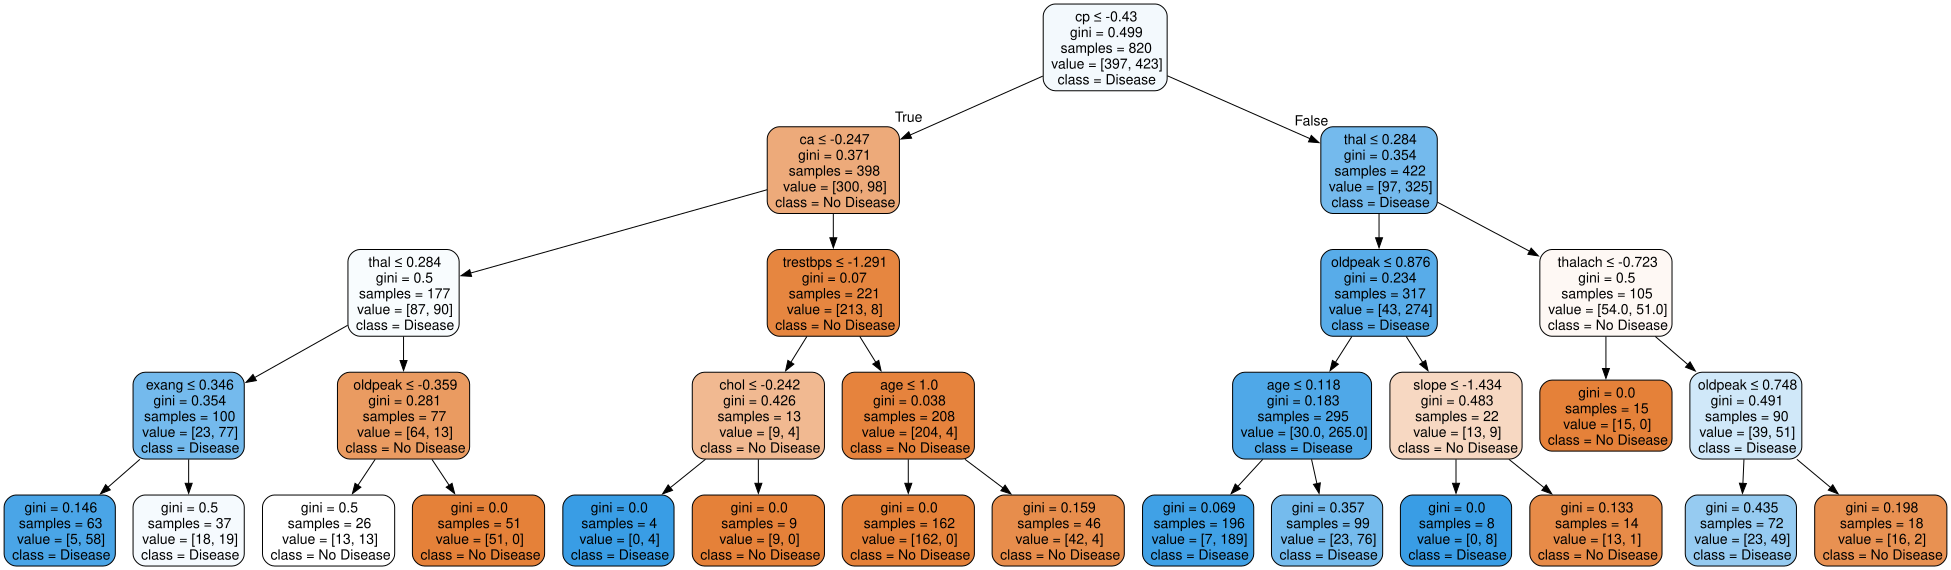

In [5]:
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score
import graphviz

dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

dot_data = export_graphviz(dt, out_file=None, feature_names=X.columns, class_names=["No Disease", "Disease"], 
                           filled=True, rounded=True, special_characters=True)
graphviz.Source(dot_data)


### 3. Analyze Overfitting with Varying Depth


In [10]:
train_acc = []
test_acc = []
depths = range(1, 11)

for d in depths:
    model = DecisionTreeClassifier(max_depth=d, random_state=42)
    model.fit(X_train, y_train)
    train_acc.append(model.score(X_train, y_train))
    test_acc.append(model.score(X_test, y_test))


### 4. Train Random Forest and Compare Accuracy

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))


Random Forest Accuracy: 0.9853658536585366


### 5. Feature Importance and Cross-Validation

In [16]:
from sklearn.model_selection import cross_val_score
import numpy as np

importances = rf.feature_importances_
for name, val in sorted(zip(X.columns, importances), key=lambda x: x[1], reverse=True):
    print(f"{name}: {val:.4f}")

cv_score = cross_val_score(rf, X, y, cv=5)
print("Cross-validation accuracy:", np.mean(cv_score))


cp: 0.1351
ca: 0.1273
thalach: 0.1222
oldpeak: 0.1219
thal: 0.1105
age: 0.0779
chol: 0.0748
trestbps: 0.0712
exang: 0.0576
slope: 0.0458
sex: 0.0287
restecg: 0.0186
fbs: 0.0084
Cross-validation accuracy: 0.9970731707317073
